In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

RNG = 42

## 1. Nap du lieu


In [2]:
DATA_DIR = r"D:\Hoc-May\Lam_Bai_Lab\01-Phan-loai\TT-09-AdaBoost\data"


cols = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty",
]


train = pd.read_csv(os.path.join(DATA_DIR, "KDDTrain+.txt"), header=None, names=cols)
test_full = pd.read_csv(os.path.join(DATA_DIR, "KDDTest+.txt"), header=None, names=cols)
test_hard = pd.read_csv(os.path.join(DATA_DIR, "KDDTest-21.txt"), header=None, names=cols)  # subset kho hon, 21% loai bo

print(train.shape, test_full.shape, test_hard.shape)
train.head()

(125973, 43) (22544, 43) (11850, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
for df in (train, test_full, test_hard):
    df["y"] = (df["label"] != "normal").astype(int)
    df.drop(columns=["difficulty"], inplace=True)

print("ty le attack trong train:", train["y"].mean())
train["label"].value_counts().head(10)

ty le attack trong train: 0.4654171925730117


label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

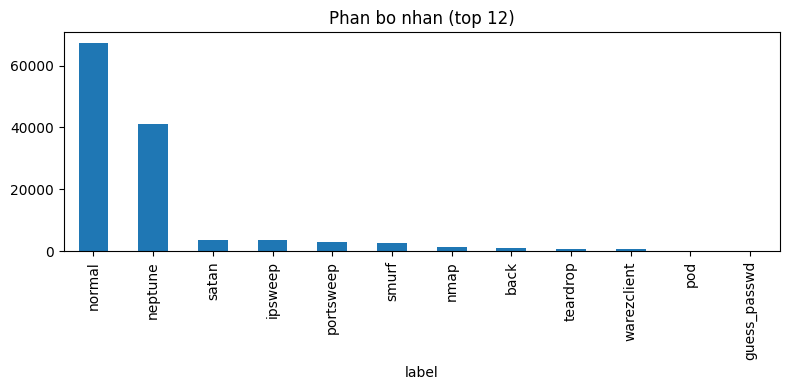

In [4]:
plt.figure(figsize=(8,4))
train["label"].value_counts().head(12).plot(kind="bar")
plt.title("Phan bo nhan (top 12)")
plt.tight_layout()
plt.savefig("../reports/eda_overview.png", dpi=110)
plt.show()

## 3. Tach X/y, one-hot 3 cot categorical, scale so

In [5]:
cat_cols = ["protocol_type", "service", "flag"]
num_cols = [c for c in cols if c not in cat_cols + ["label", "difficulty"]]

X = train.drop(columns=["label", "y"])
y = train["y"]

X_train, X_cv, y_train, y_cv = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RNG)

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

## 4. Baseline: Dummy va 1 stump

In [6]:
dummy = Pipeline([("pre", pre), ("clf", DummyClassifier(strategy="most_frequent"))])
dummy.fit(X_train, y_train)
print("Dummy F1:", f1_score(y_cv, dummy.predict(X_cv)))

stump = Pipeline([("pre", pre), ("clf", DecisionTreeClassifier(max_depth=1, random_state=RNG))])
stump.fit(X_train, y_train)
f1_stump = f1_score(y_cv, stump.predict(X_cv))
print("1 stump F1:", f1_stump)

Dummy F1: 0.0
1 stump F1: 0.9151338865600137


## 5. AdaBoost 300 stumps

In [7]:
ada = Pipeline([
    ("pre", pre),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RNG),
        n_estimators=300, learning_rate=0.5, random_state=RNG)),
])
ada.fit(X_train, y_train)
f1_ada = f1_score(y_cv, ada.predict(X_cv))
print(f"AdaBoost F1: {f1_ada:.4f}  (so voi 1 stump: {f1_stump:.4f})")

AdaBoost F1: 0.9843  (so voi 1 stump: 0.9151)


## 6. F1 theo so vong lap (staged_predict)

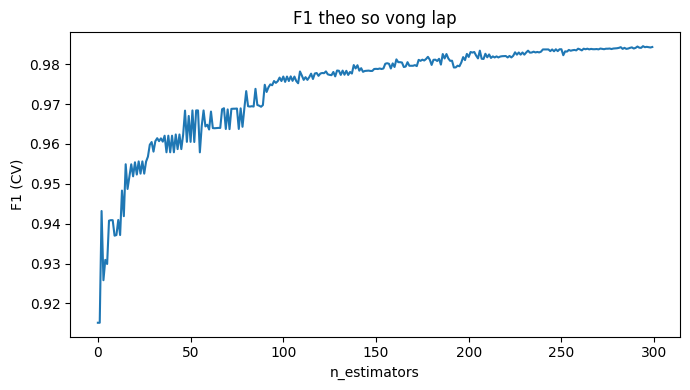

In [8]:
Xt_cv = ada.named_steps["pre"].transform(X_cv)
f1_curve = [f1_score(y_cv, p) for p in ada.named_steps["clf"].staged_predict(Xt_cv)]

plt.figure(figsize=(7,4))
plt.plot(f1_curve)
plt.xlabel("n_estimators")
plt.ylabel("F1 (CV)")
plt.title("F1 theo so vong lap")
plt.tight_layout()
plt.savefig("../reports/f1_theo_vong_lap.png", dpi=110)
plt.show()

In [9]:
rng = np.random.RandomState(RNG)
y_noisy = y_train.copy()
flip_idx = rng.choice(y_noisy.index, size=int(0.05 * len(y_noisy)), replace=False)
y_noisy.loc[flip_idx] = 1 - y_noisy.loc[flip_idx]

ada_noisy = Pipeline([("pre", pre), ("clf", AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RNG),
    n_estimators=300, learning_rate=0.5, random_state=RNG))])
ada_noisy.fit(X_train, y_noisy)
f1_ada_noisy = f1_score(y_cv, ada_noisy.predict(X_cv))

rf = Pipeline([("pre", pre), ("clf", RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1))])
rf.fit(X_train, y_train)
f1_rf = f1_score(y_cv, rf.predict(X_cv))

rf_noisy = Pipeline([("pre", pre), ("clf", RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1))])
rf_noisy.fit(X_train, y_noisy)
f1_rf_noisy = f1_score(y_cv, rf_noisy.predict(X_cv))

print("AdaBoost:      sach", f1_ada, "-> nhieu", f1_ada_noisy, "  tut", (f1_ada-f1_ada_noisy)/f1_ada*100, "%")
print("RandomForest:  sach", f1_rf, "-> nhieu", f1_rf_noisy, "  tut", (f1_rf-f1_rf_noisy)/f1_rf*100, "%")

AdaBoost:      sach 0.9843413920674524 -> nhieu 0.9730074931880109   tut 1.151419514690571 %
RandomForest:  sach 0.9990188131905635 -> nhieu 0.9928562262052445   tut 0.6168639573100312 %


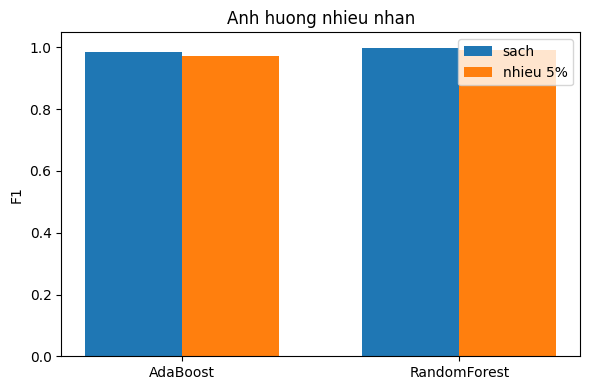

In [10]:
plt.figure(figsize=(6,4))
x = np.arange(2); w = 0.35
plt.bar(x-w/2, [f1_ada, f1_rf], w, label="sach")
plt.bar(x+w/2, [f1_ada_noisy, f1_rf_noisy], w, label="nhieu 5%")
plt.xticks(x, ["AdaBoost", "RandomForest"])
plt.ylabel("F1")
plt.legend()
plt.title("Anh huong nhieu nhan")
plt.tight_layout()
plt.savefig("../reports/thi_nghiem_nhieu.png", dpi=110)
plt.show()

**Nhan xet:** AdaBoost tang trong so cac mau bi phan sai qua tung vong. Mau bi gan nhan sai thi luon "sai" duoi mat cac stump sau, trong so no cu tang mai -> model ton nhieu suc de co gang khop dung 1 diem rac. Random Forest dung bagging (moi cay chi thay 1 phan du lieu, doc lap nhau) nen it nhay hon voi vai nhan nhieu. Ket qua so lieu o tren cung cho thay dung dieu do: AdaBoost tut % nhieu hon RF.

## 8. So sanh AdaBoost vs GradientBoosting vs RandomForest

AdaBoost F1: 0.9843413920674524
GradientBoosting F1: 0.997610513739546
RandomForest F1: 0.9990188131905635


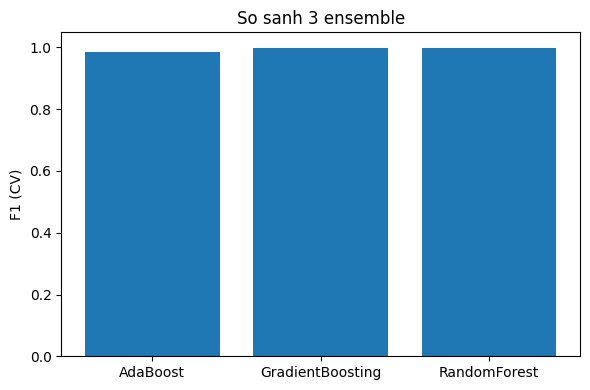

In [11]:
gb = Pipeline([("pre", pre), ("clf", GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=RNG))])
gb.fit(X_train, y_train)
f1_gb = f1_score(y_cv, gb.predict(X_cv))

print("AdaBoost F1:", f1_ada)
print("GradientBoosting F1:", f1_gb)
print("RandomForest F1:", f1_rf)

plt.figure(figsize=(6,4))
plt.bar(["AdaBoost", "GradientBoosting", "RandomForest"], [f1_ada, f1_gb, f1_rf])
plt.ylabel("F1 (CV)")
plt.title("So sanh 3 ensemble")
plt.tight_layout()
plt.savefig("../reports/so_sanh_ensemble.png", dpi=110)
plt.show()

## 9. Danh gia tren test goc (co tan cong la / zero-day) + subset kho hon KDDTest-21

In [12]:
X_test = test_full.drop(columns=["label", "y"])
y_test = test_full["y"]
pred_test = ada.predict(X_test)
f1_test = f1_score(y_test, pred_test)

X_test21 = test_hard.drop(columns=["label", "y"])
y_test21 = test_hard["y"]
pred_test21 = ada.predict(X_test21)
f1_test21 = f1_score(y_test21, pred_test21)

print(f"F1 CV (cung phan bo train):   {f1_ada:.4f}")
print(f"F1 KDDTest+ (co zero-day):    {f1_test:.4f}   (chenh {f1_ada-f1_test:.4f})")
print(f"F1 KDDTest-21 (kho hon):      {f1_test21:.4f}   (chenh {f1_ada-f1_test21:.4f})")

F1 CV (cung phan bo train):   0.9843
F1 KDDTest+ (co zero-day):    0.7590   (chenh 0.2253)
F1 KDDTest-21 (kho hon):      0.6625   (chenh 0.3219)


KDDTest-21 la subset da bo di 21% cac ban ghi de nhat (ma may KDD99 cu doan dung ~100%), nen con lai toan mau kho -> diem se thap hon KDDTest+ day du. Dung de kiem tra xem model co dang 'an may' vao mau de hay khong.

## 10. Ma tran nham lan

[[9003  708]
 [4551 8282]]


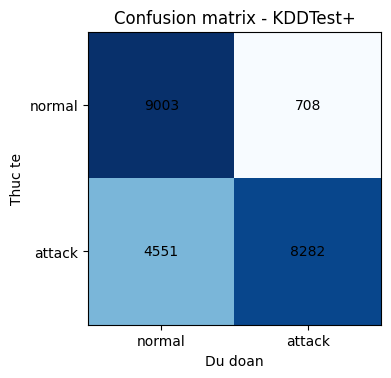

FPR = 0.0729


In [13]:
cm = confusion_matrix(y_test, pred_test)
tn, fp, fn, tp = cm.ravel()
print(cm)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.xticks([0,1], ["normal","attack"]); plt.yticks([0,1], ["normal","attack"])
plt.xlabel("Du doan"); plt.ylabel("Thuc te")
plt.title("Confusion matrix - KDDTest+")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png", dpi=110)
plt.show()

fpr = fp / (fp + tn)
print(f"FPR = {fpr:.4f}")


## 11. Luu model

In [14]:
import joblib
joblib.dump(ada, "../models/adaboost.joblib")
print("da luu")

da luu
